In [34]:
# 1. IMPORTS
import pandas as pd
import numpy as np
import boto3
import sagemaker
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score,
    recall_score, f1_score,
    roc_auc_score, confusion_matrix,
    roc_curve
)
from sagemaker.inputs import TrainingInput
from sagemaker.estimator import Estimator
from sagemaker.serializers import CSVSerializer
from sagemaker.deserializers import JSONDeserializer
from sagemaker import image_uris
from sagemaker.predictor import Predictor

# 2. LOAD DATA
data = pd.read_csv("heart.csv").dropna()
data = data.drop_duplicates()

X = data.iloc[:, :-1]
y = data.iloc[:, -1].astype(int)

# 3. TRAIN / TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# 4. FORMAT FOR SAGEMAKER
train = pd.concat([y_train.reset_index(drop=True),
                   X_train.reset_index(drop=True)], axis=1)

test = pd.concat([y_test.reset_index(drop=True),
                  X_test.reset_index(drop=True)], axis=1)

train.to_csv("train.csv", index=False, header=False)
test.to_csv("test.csv", index=False, header=False)

# 5. UPLOAD TO S3
bucket = "sagemaker-us-east-1-437258424663"
prefix = "heart-xgboost-weak"

s3 = boto3.client("s3")

s3.upload_file("train.csv", bucket, f"{prefix}/train/train.csv")
s3.upload_file("test.csv", bucket, f"{prefix}/test/test.csv")

print(" Uploaded to S3")

# 6. SAGEMAKER SETUP

session = sagemaker.Session()
role = sagemaker.get_execution_role()

container = image_uris.retrieve(
    framework="xgboost",
    region=session.boto_region_name,
    version="1.5-1"
)
estimator = Estimator(
    image_uri=container,
    role=role,
    instance_count=1,
    instance_type="ml.m5.large",
    output_path=f"s3://{bucket}/{prefix}/output",
    sagemaker_session=session,
    hyperparameters={
        "max_depth": 1,              
        "eta": 0.3,                 
        "subsample": 0.5,           
        "colsample_bytree": 0.5,    
        "num_round": 10,            
        "min_child_weight": 10,    
        "objective": "binary:logistic",
        "eval_metric": "auc"
    }
)
# 7. TRAIN MODEL
train_input = TrainingInput(
    f"s3://{bucket}/{prefix}/train/",
    content_type="text/csv"
)

estimator.fit({"train": train_input})

# 8. DEPLOY MODEL
endpoint_name = "heart-xgboost-weak-endpoint"

try:
    predictor = estimator.deploy(
        initial_instance_count=1,
        instance_type="ml.m5.large",
        endpoint_name=endpoint_name
    )
    print("Endpoint created")

except Exception:
    print(" Using existing endpoint")
    predictor = Predictor(endpoint_name=endpoint_name)

predictor.serializer = CSVSerializer()
predictor.deserializer = JSONDeserializer()

# 9. PREDICTION FUNCTION
def predict(X):
    csv = X.to_csv(header=False, index=False)
    response = predictor.predict(csv)

    if isinstance(response, dict):
        return np.array([p["score"] for p in response["predictions"]])

    return np.array(response)

# 10. PREDICTIONS
probs = predict(X_test)
y_pred = (probs > 0.5).astype(int)

# 11. METRICS
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, probs)
cm = confusion_matrix(y_test, y_pred)


print("\n MODEL RESULTS ")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"AUC      : {auc:.4f}")

print("\nConfusion Matrix:")
print(cm)


 Uploaded to S3
sagemaker.config INFO - Applied value from config key = SageMaker.PythonSDK.Modules.Session.DefaultS3Bucket
sagemaker.config INFO - Applied value from config key = SageMaker.PythonSDK.Modules.Session.DefaultS3ObjectKeyPrefix
sagemaker.config INFO - Applied value from config key = SageMaker.PythonSDK.Modules.Session.DefaultS3Bucket
sagemaker.config INFO - Applied value from config key = SageMaker.PythonSDK.Modules.Session.DefaultS3ObjectKeyPrefix
sagemaker.config INFO - Applied value from config key = SageMaker.TrainingJob.Environment
2026-04-24 14:47:12 Starting - Starting the training job...
2026-04-24 14:47:27 Starting - Preparing the instances for training...
2026-04-24 14:47:49 Downloading - Downloading input data...
2026-04-24 14:48:39 Downloading - Downloading the training image......
2026-04-24 14:49:40 Training - Training image download completed. Training in progress../miniconda3/lib/python3.8/site-packages/xgboost/compat.py:36: FutureWarning: pandas.Int64Index

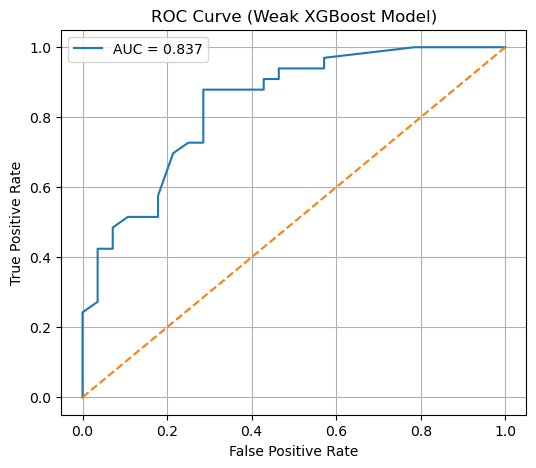

In [35]:
#  ROC CURVE PLOT
fpr, tpr, thresholds = roc_curve(y_test, probs)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Weak XGBoost Model)")
plt.legend()
plt.grid()
plt.show()

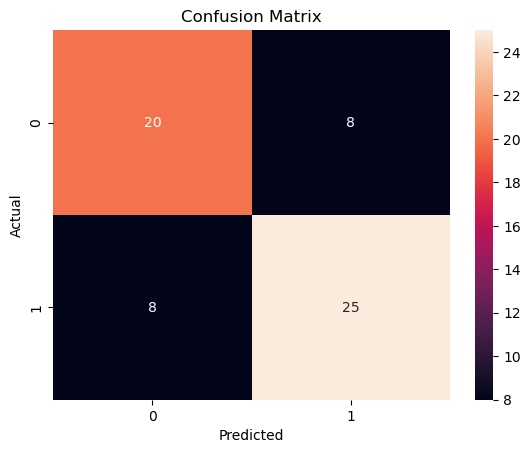

In [39]:
#confusion matrix
import seaborn as sns
cm = confusion_matrix(y_test, y_pred)
plt.figure()
sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [40]:
#classsification report
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.71      0.71      0.71        28
           1       0.76      0.76      0.76        33

    accuracy                           0.74        61
   macro avg       0.74      0.74      0.74        61
weighted avg       0.74      0.74      0.74        61



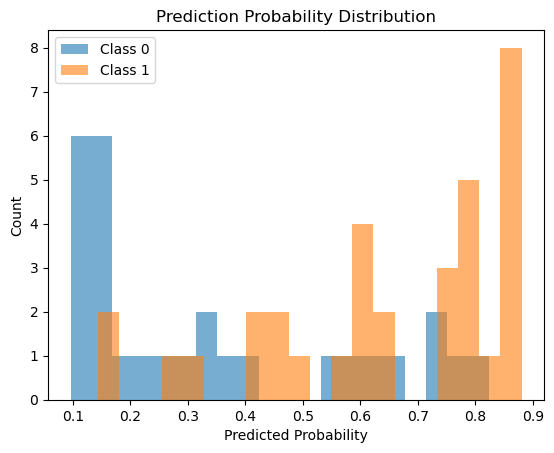

In [41]:
#prediction probability
import matplotlib.pyplot as plt
plt.hist(probs[y_test==0], bins=20, alpha=0.6, label="Class 0")
plt.hist(probs[y_test==1], bins=20, alpha=0.6, label="Class 1")
plt.xlabel("Predicted Probability")
plt.ylabel("Count")
plt.title("Prediction Probability Distribution")
plt.legend()
plt.show()